# Appliance Waveform Anomaly Detection (LSTM Autoencoder)

This notebook implements an anomaly detection model for home appliance waveform readings. 
We use an LSTM Autoencoder to reconstruct normal appliance power waveforms, operating in terms of Voltage and Current.
The model is trained on a combined dataset of normal data (REFIT dataset) and anomalous data (`fault_data.csv`), assuming Indian residential standards (230V).


In [1]:
%pip install pandas numpy matplotlib scikit-learn torch


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: C:\Users\Sandeep Balaji\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler

# Parameters
SEQ_LENGTH = 40
BATCH_SIZE = 128
EPOCHS = 10
VOLTAGE_NOMINAL = 230.0 # Indian standard voltage

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')


Using device: cpu


## Data Loading & Preprocessing
We load a sample of normal REFIT data (power) and transform it to current and voltage (230V). Then we load `fault_data.csv` which contains faults, generating time-series sequences from the fault readings. Finally, we combine both sets to train the model, as requested.

In [3]:
print('Loading REFIT dataset...')
refit_path = './REFITPowerData111215/House1.csv'
# Loading a subset (first 200,000 rows ~18 days) to manage memory and speed up training
refit_df = pd.read_csv(refit_path, header=None, nrows=200000)
# Aggregate power is in watts (column 1)
refit_power = refit_df.iloc[:, 1].values

# Generate Voltage and Current for REFIT
# Add slight noise to voltage so it's not perfectly constant (important for StandardScaler)
np.random.seed(42)
refit_voltage = np.random.normal(VOLTAGE_NOMINAL, 1.0, len(refit_power))
refit_current = refit_power / VOLTAGE_NOMINAL
refit_data = np.column_stack((refit_voltage, refit_current))

# Sequence REFIT data
num_refit_seqs = len(refit_data) // SEQ_LENGTH
refit_sequences = []
for i in range(num_refit_seqs):
    seq = refit_data[i*SEQ_LENGTH : (i+1)*SEQ_LENGTH]
    refit_sequences.append(seq)
refit_sequences = np.array(refit_sequences)
print(f'Normal REFIT sequences shape: {refit_sequences.shape}')


Loading REFIT dataset...


Normal REFIT sequences shape: (5000, 40, 2)


In [4]:
print('Loading fault dataset...')
fault_path = './fault_data.csv'
fault_df = pd.read_csv(fault_path)
fault_voltage = fault_df['Voltage (V)'].values
fault_current = fault_df['Current (A)'].values

# Create synthetic time series for faults by repeating single-point faults over a window
fault_sequences = []
for v, i in zip(fault_voltage, fault_current):
    v_seq = np.random.normal(v, 0.5, SEQ_LENGTH)
    i_seq = np.random.normal(i, 0.5, SEQ_LENGTH)
    fault_sequences.append(np.column_stack((v_seq, i_seq)))
fault_sequences = np.array(fault_sequences)
print(f'Fault sequences shape: {fault_sequences.shape}')


Loading fault dataset...
Fault sequences shape: (506, 40, 2)


In [5]:
print('Combining and standardizing datasets...')
# Combine datasets (both REFIT and faults used for training)
all_sequences = np.concatenate([refit_sequences, fault_sequences], axis=0)

# We keep track of normal vs anomaly indices for evaluation
labels = np.zeros(len(all_sequences))
labels[len(refit_sequences):] = 1 # 1 indicates anomaly from fault_data.csv

# Normalize data
scaler = StandardScaler()
# Reshape to 2D for scaler
all_data_2d = all_sequences.reshape(-1, 2)
all_data_2d_scaled = scaler.fit_transform(all_data_2d)
all_sequences_scaled = all_data_2d_scaled.reshape(all_sequences.shape)

# Convert to PyTorch tensors
tensor_X = torch.tensor(all_sequences_scaled, dtype=torch.float32)
dataset = TensorDataset(tensor_X)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)


Combining and standardizing datasets...


## LSTM Autoencoder Model
We build an encoder-decoder architecture using LSTMs.

In [6]:
class LSTMAutoencoder(nn.Module):
    def __init__(self, input_dim=2, hidden_dim=32, num_layers=1):
        super(LSTMAutoencoder, self).__init__()
        # Encoder
        self.encoder = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)
        # Decoder
        self.decoder = nn.LSTM(hidden_dim, input_dim, num_layers, batch_first=True)
        
    def forward(self, x):
        # x shape: (batch, seq_len, input_dim)
        _, (hidden, _) = self.encoder(x)
        # hidden shape: (num_layers, batch, hidden_dim)
        
        # We repeat the hidden state seq_len times to feed into the decoder
        hidden = hidden[-1].unsqueeze(1) # shape: (batch, 1, hidden_dim)
        hidden_rep = hidden.repeat(1, x.size(1), 1) # shape: (batch, seq_len, hidden_dim)
        
        # Decode
        out, _ = self.decoder(hidden_rep) # shape: (batch, seq_len, input_dim)
        return out

model = LSTMAutoencoder().to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)


## Training the Model

In [7]:
print('Training model...')
loss_history = []
for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    for batch in dataloader:
        x = batch[0].to(device)
        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, x)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    avg_loss = total_loss / len(dataloader)
    loss_history.append(avg_loss)
    print(f'Epoch {epoch+1}/{EPOCHS}, Loss: {avg_loss:.4f}')


Training model...


Epoch 1/10, Loss: 0.7513


Epoch 2/10, Loss: 0.5117


Epoch 3/10, Loss: 0.4434


Epoch 4/10, Loss: 0.4303


...

Epoch 6/10, Loss: 0.4243


Epoch 7/10, Loss: 0.4831


Epoch 8/10, Loss: 0.4223


Epoch 9/10, Loss: 0.4218


Epoch 10/10, Loss: 0.4215


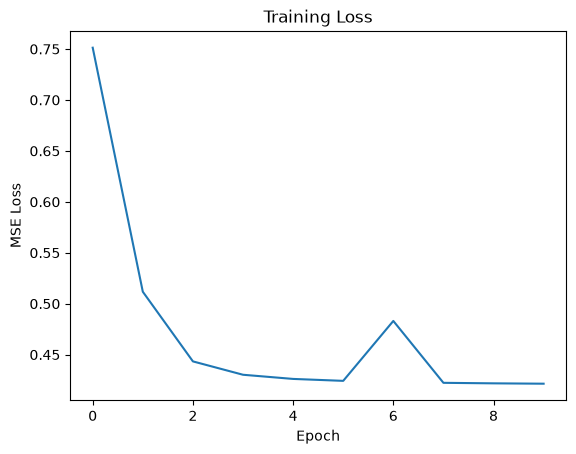

In [8]:
plt.plot(loss_history)
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.show()


## Evaluation and Anomaly Detection
We calculate the reconstruction error for all sequences. Anomalies typically have higher errors. We visualize the distributions of errors for normal vs anomalous data.

Mean Normal Error: 0.0013
Mean Anomaly Error: 4.6762


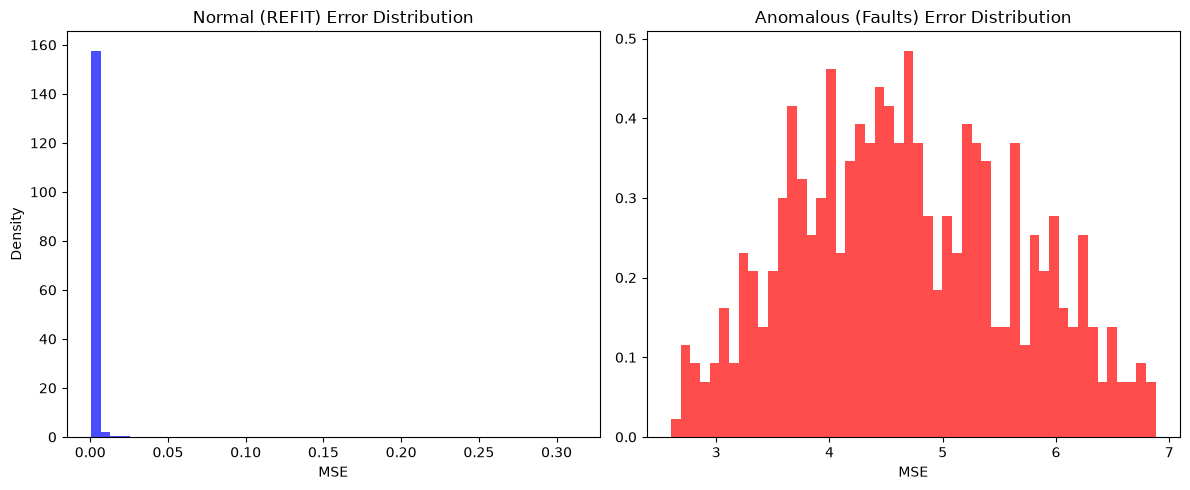

In [9]:
model.eval()
all_errors = []

eval_dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False)
with torch.no_grad():
    for batch in eval_dataloader:
        x = batch[0].to(device)
        out = model(x)
        # Calculate MSE for each sequence in the batch
        error = torch.mean((out - x)**2, dim=[1,2])
        all_errors.extend(error.cpu().numpy())

all_errors = np.array(all_errors)

# Separate errors
normal_errors = all_errors[labels == 0]
anomaly_errors = all_errors[labels == 1]

print(f'Mean Normal Error: {np.mean(normal_errors):.4f}')
print(f'Mean Anomaly Error: {np.mean(anomaly_errors):.4f}')

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(normal_errors, bins=50, alpha=0.7, color='blue', density=True)
plt.title('Normal (REFIT) Error Distribution')
plt.xlabel('MSE')
plt.ylabel('Density')

plt.subplot(1, 2, 2)
plt.hist(anomaly_errors, bins=50, alpha=0.7, color='red', density=True)
plt.title('Anomalous (Faults) Error Distribution')
plt.xlabel('MSE')

plt.tight_layout()
plt.show()
